In [20]:
import pandas as pd
import numpy as np

In [21]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df['Contract'].head()

0    Month-to-month
1          One year
2    Month-to-month
3          One year
4    Month-to-month
Name: Contract, dtype: object

In [24]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df=df.drop('customerID',axis=1)
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

C:\Users\ARPIT\AppData\Local\Temp\ipykernel_12948\3170409733.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['TotalCharges'])


<Axes: xlabel='TotalCharges', ylabel='Density'>

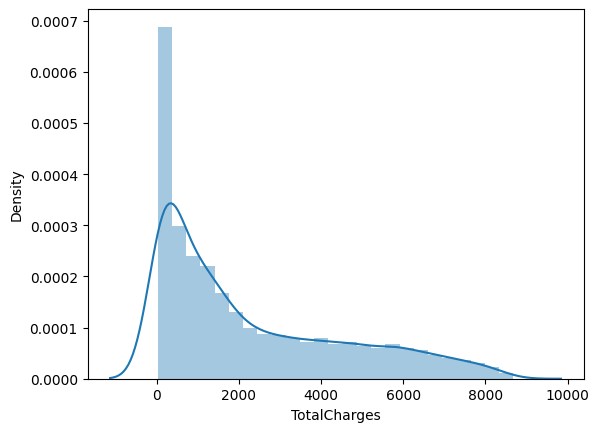

In [27]:
import seaborn as sns
sns.distplot(df['TotalCharges']) 

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer

In [29]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [42]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Churn',axis=1),df['Churn'],random_state=42,test_size=0.2)
imputing=['TotalCharges']
categorical_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]
scaling=['SeniorCitizen','tenure','MonthlyCharges']
pipe_scale1=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='median')), 
    ('scale1',FunctionTransformer(func=np.log1p))
])
pipe_scale2=Pipeline(steps=[
    ('scale2',StandardScaler())
])
pipe_encoding=Pipeline(steps=[
    ('encode',OneHotEncoder(drop='first',handle_unknown='ignore'))
])
transformer1=ColumnTransformer(transformers=[
   ('scale1',pipe_scale1,['TotalCharges']),
    ('scale2',pipe_scale2,scaling),
    ('encode',pipe_encoding,categorical_cols),
],remainder='passthrough')

In [46]:
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [84]:
y_train_transform=np.where(y_train=='Yes',1,0)
y_test_transform=np.where(y_test=='Yes',1,0)
pipe1=Pipeline(steps=[
    ('transformer1',transformer1),
    ('model',RandomForestClassifier())
])
pipe2=Pipeline(steps=[
    ('transformer1',transformer1),
    ('model2',XGBClassifier( n_estimators=700,max_depth=2,learning_rate=0.06))
])

In [86]:
#y_train_transform=np.where(y_train=='yes',1,0)
pipe2.fit(X_train,y_train_transform)
y_pred=pipe2.predict(X_test)
accuracy=accuracy_score(y_test_transform,y_pred)
precision_score=precision_score(y_test_transform,y_pred)
recall_score=recall_score(y_test_transform,y_pred)
f1_score=f1_score(y_test_transform,y_pred)
print(accuracy)
print(precision_score)
print(recall_score)
print(f1_score)

0.8133427963094393
0.6729559748427673
0.5737265415549598
0.6193921852387844
